In [679]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


In [680]:
df_train=pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')
df_test=pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_test.csv')

In [681]:
df_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [682]:
df=pd.concat((df_train,df_test))

In [683]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [684]:
integer=[]
numerical=[]
categorical=[]
for col in df.columns:
    if df[col].dtype =='int64':
        integer.append(col)
    elif df[col].dtype == 'object':
        categorical.append(col)
    elif df[col].dtype=='float64':
        numerical.append(col)
        
        

In [685]:
# Conclusion : Seperated columns of different dtypes

In [686]:
df.shape

(356255, 122)

In [687]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356255 entries, 0 to 48743
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(66), int64(40), object(16)
memory usage: 334.3+ MB


In [688]:
df.describe()  

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,356255.000000,307511.000000,356255.000000,3.562550e+05,3.562550e+05,356219.000000,3.559770e+05,356255.000000,356255.000000,356255.000000,...,356255.000000,356255.000000,356255.000000,356255.000000,308687.000000,308687.000000,308687.000000,308687.000000,308687.000000,308687.000000
mean,278128.000000,0.080729,0.414316,1.701161e+05,5.877674e+05,27425.560657,5.280200e+05,0.020917,-16041.248841,64317.231413,...,0.007231,0.000514,0.000438,0.000289,0.005808,0.006281,0.029995,0.231697,0.304399,1.911564
std,102842.104413,0.272419,0.720378,2.235068e+05,3.986237e+05,14732.808190,3.660650e+05,0.013915,4358.803980,141705.532576,...,0.084726,0.022659,0.020921,0.017001,0.079736,0.104250,0.191374,0.855949,0.786915,1.865338
min,100001.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000253,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189064.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16731.000000,2.340000e+05,0.010006,-19676.000000,-2781.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278128.000000,0.000000,0.000000,1.530000e+05,5.002110e+05,25078.500000,4.500000e+05,0.018850,-15755.000000,-1224.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367191.500000,0.000000,1.000000,2.025000e+05,7.975575e+05,34960.500000,6.750000e+05,0.028663,-12425.000000,-290.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,20.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7338.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [689]:
# conclusion: integer doesnt have any null
numerical_missing=[]
for i in numerical:
     print(i,'-->',df[i].isnull().sum())
     if (df[i].isnull().sum()/356255)*100>50:
        numerical_missing.append(i)
        

TARGET --> 48744
AMT_INCOME_TOTAL --> 0
AMT_CREDIT --> 0
AMT_ANNUITY --> 36
AMT_GOODS_PRICE --> 278
REGION_POPULATION_RELATIVE --> 0
DAYS_REGISTRATION --> 0
OWN_CAR_AGE --> 235241
CNT_FAM_MEMBERS --> 2
EXT_SOURCE_1 --> 193910
EXT_SOURCE_2 --> 668
EXT_SOURCE_3 --> 69633
APARTMENTS_AVG --> 179948
BASEMENTAREA_AVG --> 207584
YEARS_BEGINEXPLUATATION_AVG --> 172863
YEARS_BUILD_AVG --> 236306
COMMONAREA_AVG --> 248360
ELEVATORS_AVG --> 189080
ENTRANCES_AVG --> 178407
FLOORSMAX_AVG --> 176341
FLOORSMIN_AVG --> 241108
LANDAREA_AVG --> 210844
LIVINGAPARTMENTS_AVG --> 242979
LIVINGAREA_AVG --> 177902
NONLIVINGAPARTMENTS_AVG --> 246861
NONLIVINGAREA_AVG --> 195766
APARTMENTS_MODE --> 179948
BASEMENTAREA_MODE --> 207584
YEARS_BEGINEXPLUATATION_MODE --> 172863
YEARS_BUILD_MODE --> 236306
COMMONAREA_MODE --> 248360
ELEVATORS_MODE --> 189080
ENTRANCES_MODE --> 178407
FLOORSMAX_MODE --> 176341
FLOORSMIN_MODE --> 241108
LANDAREA_MODE --> 210844
LIVINGAPARTMENTS_MODE --> 242979
LIVINGAREA_MODE --> 17790

In [690]:
for i in numerical_missing:
    print(i, ':', df[i].corr(df['TARGET']))

OWN_CAR_AGE : 0.03761156427516558
EXT_SOURCE_1 : -0.15531712606394885
APARTMENTS_AVG : -0.029497564633431665
BASEMENTAREA_AVG : -0.022745743190148025
YEARS_BUILD_AVG : -0.0221492840633888
COMMONAREA_AVG : -0.018549661629760385
ELEVATORS_AVG : -0.03419879367526813
ENTRANCES_AVG : -0.01917218201273824
FLOORSMIN_AVG : -0.03361350325189984
LANDAREA_AVG : -0.010884822678806673
LIVINGAPARTMENTS_AVG : -0.025030533291064416
NONLIVINGAPARTMENTS_AVG : -0.003176107520726144
NONLIVINGAREA_AVG : -0.013578069781984798
APARTMENTS_MODE : -0.02728387066775316
BASEMENTAREA_MODE : -0.01995228392431528
YEARS_BUILD_MODE : -0.022068203834856533
COMMONAREA_MODE : -0.01634033731130413
ELEVATORS_MODE : -0.03213117100499517
ENTRANCES_MODE : -0.017387422304882993
FLOORSMIN_MODE : -0.03269782531047499
LANDAREA_MODE : -0.010174103567660462
LIVINGAPARTMENTS_MODE : -0.02339324557019748
NONLIVINGAPARTMENTS_MODE : -0.0015565608459037733
NONLIVINGAREA_MODE : -0.012710543748878218
APARTMENTS_MEDI : -0.029183758876693566

Conclusion : here only ext_source 1 is having best corr , rest of them are having corr , so dropping them from data 

In [691]:
numerical_missing.remove('EXT_SOURCE_1')

In [692]:
df.drop(columns=numerical_missing,inplace=True)

**Removed columns having missing values more than 50 % and weak corr with target**

In [693]:
numerical=[]
for col in df.columns:
    if df[col].dtype=='float64':
        numerical.append(col)

In [694]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356255 entries, 0 to 48743
Data columns (total 88 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   SK_ID_CURR                    356255 non-null  int64  
 1   TARGET                        307511 non-null  float64
 2   NAME_CONTRACT_TYPE            356255 non-null  object 
 3   CODE_GENDER                   356255 non-null  object 
 4   FLAG_OWN_CAR                  356255 non-null  object 
 5   FLAG_OWN_REALTY               356255 non-null  object 
 6   CNT_CHILDREN                  356255 non-null  int64  
 7   AMT_INCOME_TOTAL              356255 non-null  float64
 8   AMT_CREDIT                    356255 non-null  float64
 9   AMT_ANNUITY                   356219 non-null  float64
 10  AMT_GOODS_PRICE               355977 non-null  float64
 11  NAME_TYPE_SUITE               354052 non-null  object 
 12  NAME_INCOME_TYPE              356255 non-null  obj

In [695]:
for i in numerical:
    df[i]=df[i].fillna(df[i].median())

**Imputed median values to missing values in numerical columns and will use Model based imputation if result not so good**

In [696]:
for i in categorical:
    print(i,df[i].isnull().sum())

NAME_CONTRACT_TYPE 0
CODE_GENDER 0
FLAG_OWN_CAR 0
FLAG_OWN_REALTY 0
NAME_TYPE_SUITE 2203
NAME_INCOME_TYPE 0
NAME_EDUCATION_TYPE 0
NAME_FAMILY_STATUS 0
NAME_HOUSING_TYPE 0
OCCUPATION_TYPE 111996
WEEKDAY_APPR_PROCESS_START 0
ORGANIZATION_TYPE 0
FONDKAPREMONT_MODE 243092
HOUSETYPE_MODE 177916
WALLSMATERIAL_MODE 180234
EMERGENCYSTATE_MODE 167964


In [697]:
categorical_missing=[]
for i in categorical:
    if df[i].isnull().sum()>0:
        categorical_missing.append(i)
        

In [698]:
for i in categorical_missing:
    df[i]=df[i].fillna('Unknown')

**Filled the missing values with unknown bcz values were not missed at random, people may left it bcz it was not applicable to them**

# Feature selection 

In [699]:
integer1=[]
numerical1=[]
categorical1=[]
for col in df.columns:
    if df[col].dtype =='int64':
        integer1.append(col)
    elif df[col].dtype == 'object':
        categorical1.append(col)
    elif df[col].dtype=='float64':
        numerical1.append(col)

In [700]:
for i in numerical1:
    print(i,df[i].corr(df['TARGET']))

TARGET 0.9999999999999998
AMT_INCOME_TOTAL -0.005515511054116462
AMT_CREDIT -0.02058953578460918
AMT_ANNUITY -0.017529258195170767
AMT_GOODS_PRICE -0.02918344501954415
REGION_POPULATION_RELATIVE -0.03513611673837957
DAYS_REGISTRATION 0.03852455703500389
CNT_FAM_MEMBERS 0.008865633465449413
EXT_SOURCE_1 -0.08947471042123685
EXT_SOURCE_2 -0.1497368828531711
EXT_SOURCE_3 -0.14233869844092828
YEARS_BEGINEXPLUATATION_AVG -0.004850356705115371
FLOORSMAX_AVG -0.03789042334026568
LIVINGAREA_AVG -0.02835633470158381
YEARS_BEGINEXPLUATATION_MODE -0.004291975241139166
FLOORSMAX_MODE -0.03689430572525469
LIVINGAREA_MODE -0.026876217447095428
YEARS_BEGINEXPLUATATION_MEDI -0.005031418077164029
FLOORSMAX_MEDI -0.03765159921912941
LIVINGAREA_MEDI -0.028202310940701317
TOTALAREA_MODE -0.029077488143411555
OBS_30_CNT_SOCIAL_CIRCLE 0.00763456177842777
DEF_30_CNT_SOCIAL_CIRCLE 0.029214160918308255
OBS_60_CNT_SOCIAL_CIRCLE 0.007462650231866534
DEF_60_CNT_SOCIAL_CIRCLE 0.02838614807902637
DAYS_LAST_PHONE_CH

**Not able to decide using correlation**

**Now i will use variance concept, columns with high correlation and model based approach to remove non important columns**

In [701]:
# now going to use variance approach , remove columns with very low variance 
from sklearn.feature_selection import VarianceThreshold

X_num = df[numerical1]

selector = VarianceThreshold(threshold=0.01)

selector.fit(X_num)

selected_num = X_num.columns[selector.get_support()]
removed_num = X_num.columns[~selector.get_support()]
# get support means those columns who are satisdfying the condition threshold=0.01

In [702]:
print(selected_num)

Index(['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'DAYS_REGISTRATION', 'CNT_FAM_MEMBERS',
       'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLOORSMAX_AVG',
       'FLOORSMAX_MODE', 'FLOORSMAX_MEDI', 'OBS_30_CNT_SOCIAL_CIRCLE',
       'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
       'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object')


In [703]:
print(removed_num)

Index(['REGION_POPULATION_RELATIVE', 'YEARS_BEGINEXPLUATATION_AVG',
       'LIVINGAREA_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'LIVINGAREA_MODE',
       'YEARS_BEGINEXPLUATATION_MEDI', 'LIVINGAREA_MEDI', 'TOTALAREA_MODE',
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY'],
      dtype='object')


In [704]:
for i in numerical1:
    print(i,'-->',df[i].var())

TARGET --> 0.06482766159169508
AMT_INCOME_TOTAL --> 49955298143.44032
AMT_CREDIT --> 158900849191.02817
AMT_ANNUITY --> 217034259.96246493
AMT_GOODS_PRICE --> 133903751420.33559
REGION_POPULATION_RELATIVE --> 0.00019362683141013143
DAYS_REGISTRATION --> 12439510.229272248
CNT_FAM_MEMBERS --> 0.8243458551707791
EXT_SOURCE_1 --> 0.02010925123468634
EXT_SOURCE_2 --> 0.035943407295812815
EXT_SOURCE_3 --> 0.030415357592579725
YEARS_BEGINEXPLUATATION_AVG --> 0.0017309057511303617
FLOORSMAX_AVG --> 0.011544288724158016
LIVINGAREA_AVG --> 0.006465243459371063
YEARS_BEGINEXPLUATATION_MODE --> 0.0020586186575976147
FLOORSMAX_MODE --> 0.011291448373828492
LIVINGAREA_MODE --> 0.0066202295775617875
YEARS_BEGINEXPLUATATION_MEDI --> 0.001768852981395343
FLOORSMAX_MEDI --> 0.011590987230230387
LIVINGAREA_MEDI --> 0.006666062613279999
TOTALAREA_MODE --> 0.006359945261977553
OBS_30_CNT_SOCIAL_CIRCLE --> 6.7456026083023595
DEF_30_CNT_SOCIAL_CIRCLE --> 0.20791044643260445
OBS_60_CNT_SOCIAL_CIRCLE --> 6.63

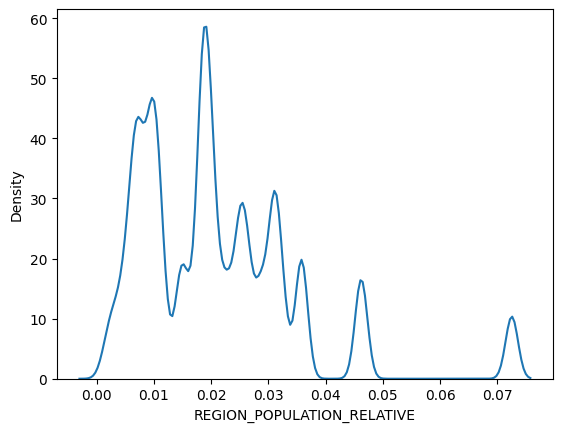

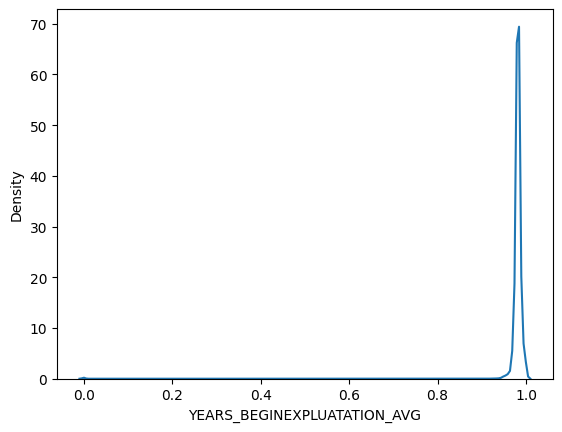

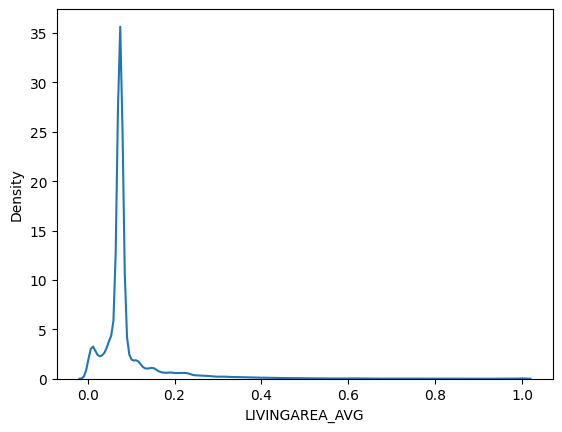

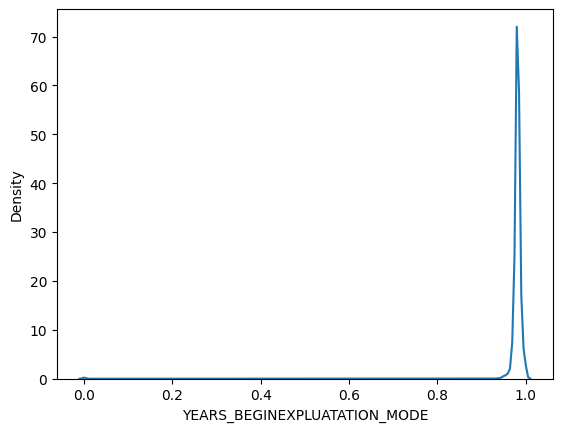

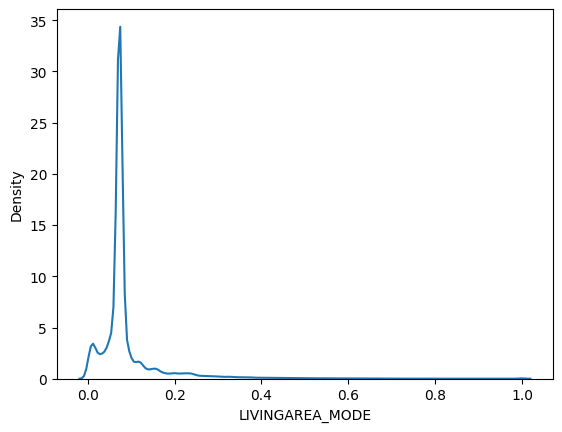

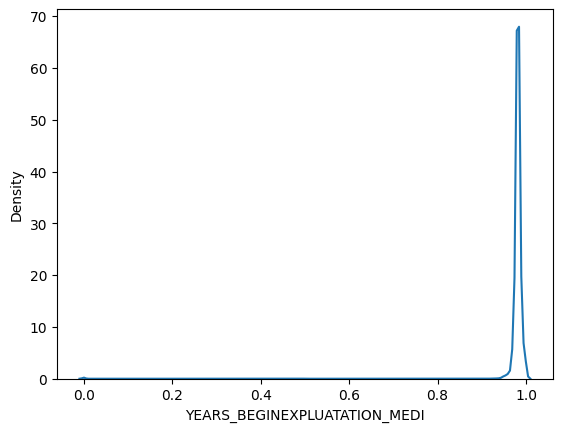

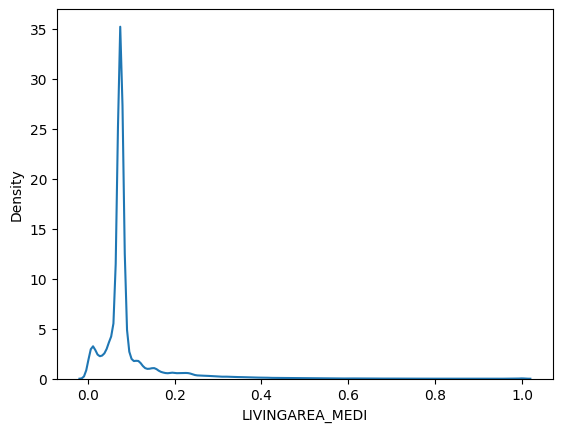

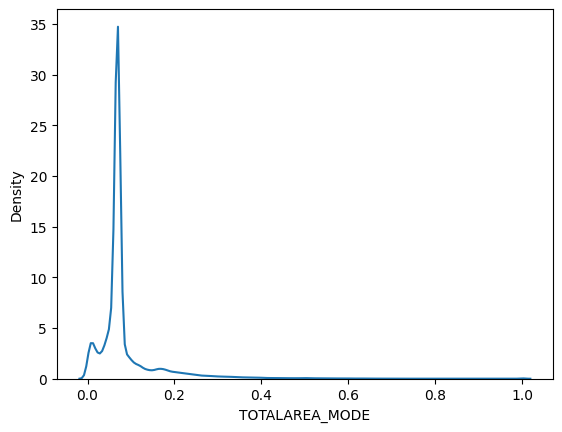

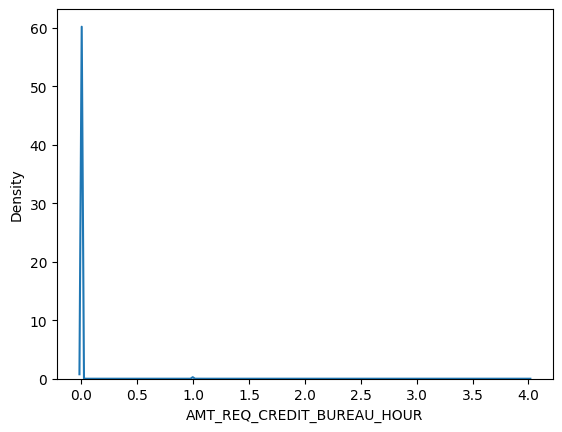

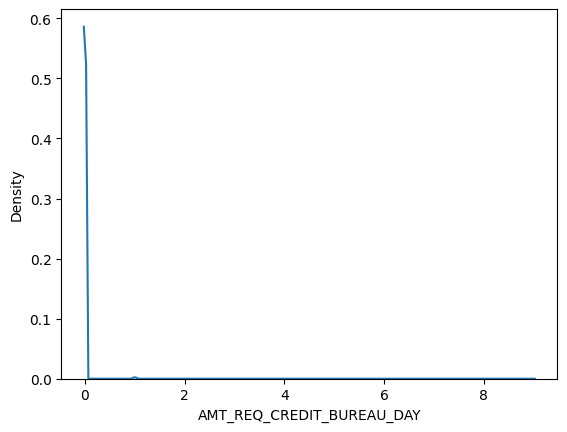

In [705]:
import matplotlib.pyplot as plt
import seaborn as sns
for i in removed_num:
    sns.kdeplot(df[i])
    plt.show()

**Conclusion** 
**After using variance threshold and plots i can say except the first one all the columns are safe to remove**

In [706]:
df.drop(columns=removed_num[1:],inplace=True)

In [707]:
integer_cat=[]
for i in integer:
    if df[i].value_counts().index.size<=5:
        integer_cat.append(i)

In [708]:
for i in integer_cat:
    print(f"\n{i}")
    print(pd.crosstab(df[i],df['TARGET']))


FLAG_MOBIL
TARGET         0.0    1.0
FLAG_MOBIL               
0                2      0
1           331428  24825

FLAG_EMP_PHONE
TARGET             0.0    1.0
FLAG_EMP_PHONE               
0                61670   2991
1               269760  21834

FLAG_WORK_PHONE
TARGET              0.0    1.0
FLAG_WORK_PHONE               
0                266048  18921
1                 65382   5904

FLAG_CONT_MOBILE
TARGET               0.0    1.0
FLAG_CONT_MOBILE               
0                    607     45
1                 330823  24780

FLAG_PHONE
TARGET         0.0    1.0
FLAG_PHONE               
0           238254  18744
1            93176   6081

FLAG_EMAIL
TARGET         0.0    1.0
FLAG_EMAIL               
0           307434  23451
1            23996   1374

REGION_RATING_CLIENT
TARGET                   0.0    1.0
REGION_RATING_CLIENT               
1                      36409   1552
2                     244433  17907
3                      50588   5366

REGION_RATING_CLIENT_W_CIT

**There are many prominant features waiting to be removed but i will do so after checking with model based approach**

In [709]:
binary_cols = [
    col for col in categorical1
    if df[col].nunique() == 2
]

remaining_cat_cols = [
    col for col in categorical1
    if df[col].nunique() > 2
]

In [710]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df = pd.get_dummies(
    df,
    columns=remaining_cat_cols,
    drop_first=True,
    dtype='int'
)

In [711]:
X = df.drop(columns=['TARGET','SK_ID_CURR'])
y = df['TARGET']

In [712]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [713]:
df.shape

(356255, 193)

In [714]:
# from sklearn.ensemble import RandomForestClassifier

# rf = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42,
#     class_weight='balanced',
#     n_jobs=-1
# )

# rf.fit(X_train, y_train)

In [715]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [716]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [717]:
y_pred=rf.predict(X_test)

In [718]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[66220    66]
 [ 4949    16]]


In [719]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_prob))

0.6849599506231944


In [720]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96     66286
         1.0       0.20      0.00      0.01      4965

    accuracy                           0.93     71251
   macro avg       0.56      0.50      0.48     71251
weighted avg       0.88      0.93      0.90     71251



In [721]:
importance = rf.feature_importances_

In [722]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

In [723]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                             Feature    Importance
31                      EXT_SOURCE_3  5.307730e-02
30                      EXT_SOURCE_2  4.047576e-02
19                   CNT_FAM_MEMBERS  3.841598e-02
35          OBS_30_CNT_SOCIAL_CIRCLE  3.576417e-02
37          OBS_60_CNT_SOCIAL_CIRCLE  3.495269e-02
..                               ...           ...
65                   CODE_GENDER_XNA  7.974105e-08
74  NAME_INCOME_TYPE_Maternity leave  7.508483e-08
87        NAME_FAMILY_STATUS_Unknown  3.549691e-08
50                  FLAG_DOCUMENT_12  0.000000e+00
13                        FLAG_MOBIL  0.000000e+00

[191 rows x 2 columns]


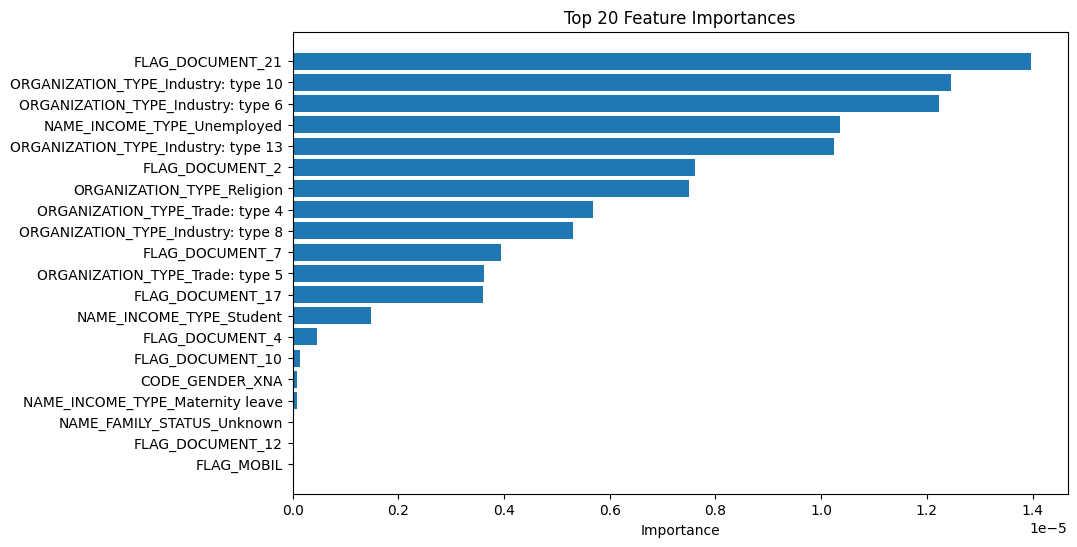

In [724]:
import matplotlib.pyplot as plt

top20 = feature_importance.tail(20)

plt.figure(figsize=(10,6))
plt.barh(top20['Feature'], top20['Importance'])
plt.gca().invert_yaxis()   # Highest importance at the top
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances")
plt.show()

In [725]:
removable_columns = feature_importance[
    feature_importance['Importance'] < 0.005
]['Feature'].tolist()


In [726]:
# df.drop(columns=removable_columns,inplace=True)

In [727]:
removable_columns

['NAME_FAMILY_STATUS_Widow',
 'ORGANIZATION_TYPE_Self-employed',
 'LIVE_CITY_NOT_WORK_CITY',
 'REGION_RATING_CLIENT_W_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'FLAG_DOCUMENT_3',
 'FLAG_EMAIL',
 'NAME_EDUCATION_TYPE_Incomplete higher',
 'WEEKDAY_APPR_PROCESS_START_SUNDAY',
 'FLAG_WORK_PHONE',
 'NAME_HOUSING_TYPE_With parents',
 'CODE_GENDER_M',
 'NAME_HOUSING_TYPE_Municipal apartment',
 'REG_CITY_NOT_LIVE_CITY',
 'FLAG_DOCUMENT_8',
 'OCCUPATION_TYPE_Managers',
 'FLAG_DOCUMENT_6',
 'FONDKAPREMONT_MODE_reg oper spec account',
 'ORGANIZATION_TYPE_Other',
 'NAME_TYPE_SUITE_Spouse, partner',
 'OCCUPATION_TYPE_Drivers',
 'ORGANIZATION_TYPE_Medicine',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'OCCUPATION_TYPE_Medicine staff',
 'OCCUPATION_TYPE_High skill tech staff',
 'NAME_INCOME_TYPE_Pensioner',
 'ORGANIZATION_TYPE_XNA',
 'FLAG_EMP_PHONE',
 'NAME_EDUCATION_TYPE_Lower secondary',
 'NAME_CONTRACT_TYPE',
 'WALLSMATERIAL_MODE_Wooden',
 'NAME_HOUSING_TYPE_Rented apartment',
 'ORGANIZATION_TYPE_Business Entity Ty

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "n_estimators":[200,300,500],
    "max_depth":[10,20,30,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

search = RandomizedSearchCV(
    rf,
    params,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_smote, y_train_smote)

best_rf = search.best_estimator_

print(search.best_params_)